# HAM10000 — Exploratory Data Analysis

Deep EDA for a 7-class skin lesion classification task on the **HAM10000**
dermatoscopy dataset. The goal is to characterize the data, quantify the class
imbalance, surface image-level differences between lesion types, and translate
the findings into concrete modeling decisions.

> **Disclaimer.** Research / educational use only. The analysis and any model
> built on it are **not** medical devices and must not be used for clinical
> decisions. HAM10000 is licensed under CC BY-NC 4.0.

**Contents**
1. Dataset overview
2. Class distribution analysis
3. Image statistics
4. Sample visualization
5. Statistical tests
6. Insights & modeling implications


In [1]:
from __future__ import annotations

from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from scipy import stats

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")

# Resolve paths whether the notebook runs from the repo root or notebooks/.
ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent
DATA_DIR = ROOT / "data"
IMAGE_DIR = DATA_DIR / "HAM10000_images"

# Full lesion names and a stable order (most -> least common).
DX_FULL = {
    "nv": "Melanocytic nevi",
    "mel": "Melanoma",
    "bkl": "Benign keratosis",
    "bcc": "Basal cell carcinoma",
    "akiec": "Actinic keratoses",
    "vasc": "Vascular lesions",
    "df": "Dermatofibroma",
}
DX_ORDER = list(DX_FULL)

print("DATA_DIR:", DATA_DIR)
print("images on disk:", len(list(IMAGE_DIR.glob("*.jpg"))))


DATA_DIR: d:\Projects\skin-lesion-classifier\data
images on disk: 10015


## 1. Dataset Overview

Load the metadata and review its structure, fields, and missing values.


In [2]:
df = pd.read_csv(DATA_DIR / "HAM10000_metadata.csv")
df["dx_name"] = df["dx"].map(DX_FULL)
print("shape:", df.shape)
df.head()


shape: (10015, 8)


,lesion_id,image_id,dx,dx_type,age,sex,localization,dx_name
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,Benign keratosis
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,Benign keratosis
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,Benign keratosis
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,Benign keratosis
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,Benign keratosis


In [3]:
print("=== dtypes ===")
print(df.dtypes)
print("\n=== missing values ===")
print(df.isna().sum())
print("\n=== lesions vs images ===")
print("unique lesion_id:", df["lesion_id"].nunique())
print("unique image_id :", df["image_id"].nunique())
dup = df["lesion_id"].value_counts()
print("lesions with >1 image:", int((dup > 1).sum()))


=== dtypes ===
lesion_id        object
image_id         object
dx               object
dx_type          object
age             float64
sex              object
localization     object
dx_name          object
dtype: object

=== missing values ===
lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dx_name          0
dtype: int64

=== lesions vs images ===
unique lesion_id: 7470
unique image_id : 10015
lesions with >1 image: 1956


**Field notes**

- `lesion_id` groups multiple images of the *same* physical lesion, so a naive
  random split would leak near-duplicate images across train/val/test. The split
  must be **lesion-aware (grouped by `lesion_id`)**.
- `dx` is the 7-class target; `dx_name` is its readable form.
- `dx_type` records how each label was confirmed (histopathology, follow-up,
  expert consensus, confocal) — a proxy for label reliability.
- `age` has a small number of missing values; `sex` / `localization` are
  categorical context features.


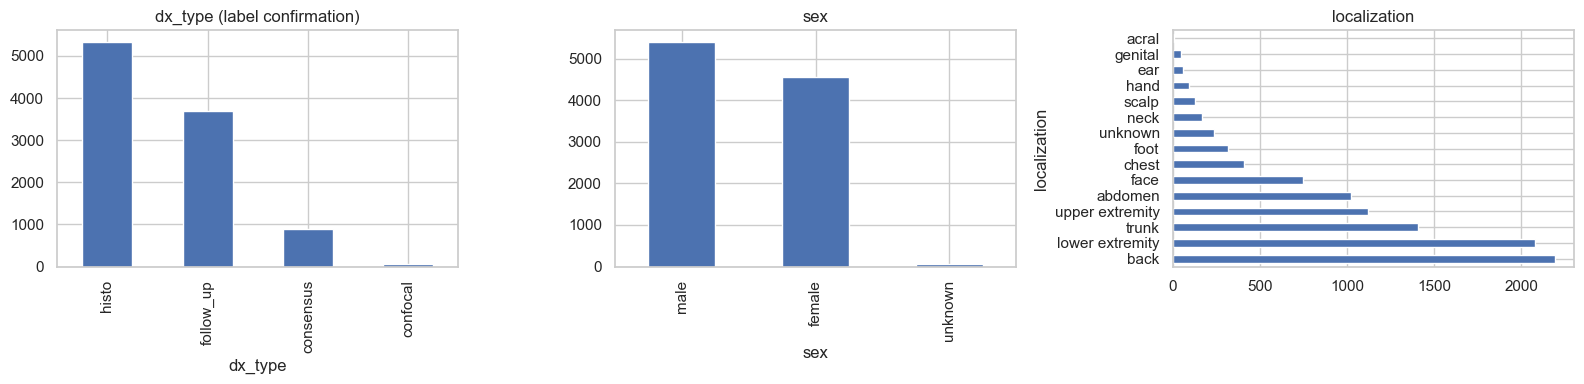

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
df["dx_type"].value_counts().plot.bar(ax=axes[0], title="dx_type (label confirmation)")
df["sex"].value_counts().plot.bar(ax=axes[1], title="sex")
df["localization"].value_counts().plot.barh(ax=axes[2], title="localization")
plt.tight_layout()
plt.show()


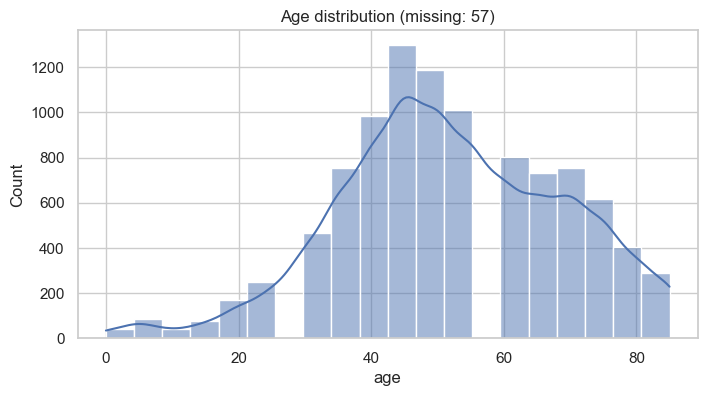

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df["age"].dropna(), bins=20, kde=True, ax=ax)
ax.set_title(f"Age distribution (missing: {int(df['age'].isna().sum())})")
ax.set_xlabel("age")
plt.show()


## 2. Class Distribution Analysis

Quantify the imbalance and derive the inverse-frequency weights used later for
class-weighted cross-entropy.


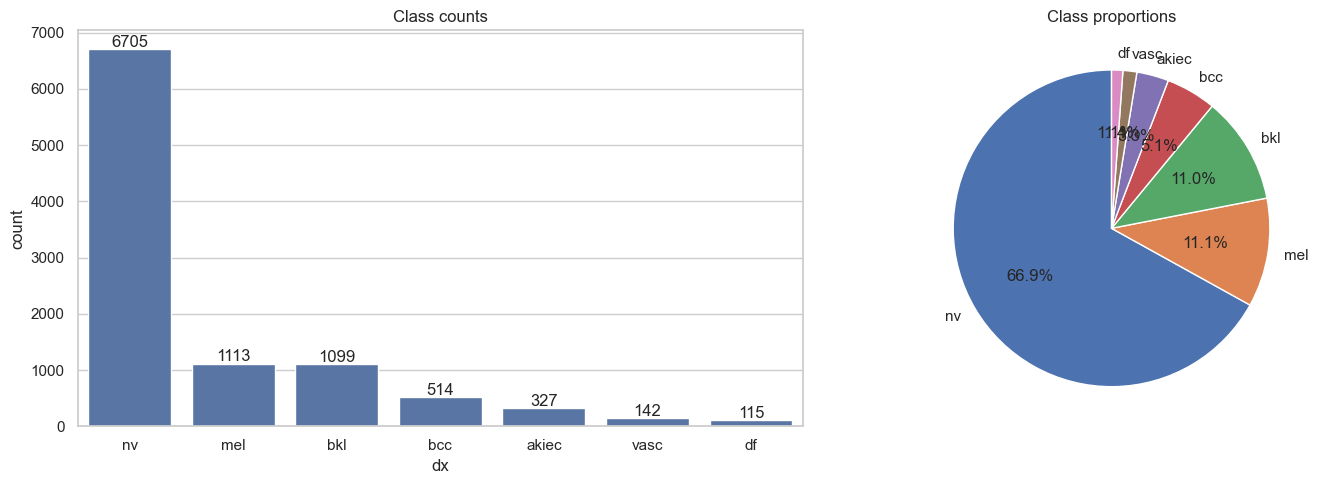

Majority: nv (6705)
Minority: df (115)
Imbalance ratio (max/min): 58.3x


In [6]:
counts = df["dx"].value_counts().reindex(DX_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(x=counts.index, y=counts.values, ax=axes[0])
axes[0].set_title("Class counts")
axes[0].set_xlabel("dx")
axes[0].set_ylabel("count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 40, str(int(v)), ha="center")
axes[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%", startangle=90)
axes[1].set_title("Class proportions")
plt.tight_layout()
plt.show()

imbalance = counts.max() / counts.min()
print(f"Majority: {counts.idxmax()} ({int(counts.max())})")
print(f"Minority: {counts.idxmin()} ({int(counts.min())})")
print(f"Imbalance ratio (max/min): {imbalance:.1f}x")


In [7]:
# Inverse-frequency weights (normalized) for class-weighted cross-entropy.
weights = len(df) / (len(DX_ORDER) * counts)
weights = (weights / weights.sum() * len(DX_ORDER)).round(3)
print("Inverse-frequency class weights:")
print(weights)


Inverse-frequency class weights:
dx
nv       0.046
mel      0.277
bkl      0.281
bcc      0.600
akiec    0.943
vasc     2.172
df       2.682
Name: count, dtype: float64


With a **~58x** majority-to-minority ratio, overall accuracy is dominated by
`nv` and is therefore misleading. Evaluation must emphasize **per-class
sensitivity (recall)**, **macro-F1**, and **macro-AUC**, and training should
counter the imbalance via **class-weighted CE** and **Focal Loss**.


## 3. Image Statistics

Per-class color / brightness / contrast / saturation, computed on a stratified
sample for tractability (loading ~1–2k images may take ~1–2 minutes).


In [8]:
SAMPLE_PER_CLASS = 200

parts = [g.sample(min(len(g), SAMPLE_PER_CLASS), random_state=SEED)
         for _, g in df.groupby("dx")]
sample_df = pd.concat(parts).reset_index(drop=True)
print(f"Computing image statistics on {len(sample_df)} sampled images...")


def image_stats(image_id: str) -> dict:
    img = Image.open(IMAGE_DIR / f"{image_id}.jpg").convert("RGB")
    arr = np.asarray(img, dtype=np.float32) / 255.0
    lum = 0.299 * arr[..., 0] + 0.587 * arr[..., 1] + 0.114 * arr[..., 2]
    sat = np.asarray(img.convert("HSV"), dtype=np.float32)[..., 1] / 255.0
    return {
        "mean_r": arr[..., 0].mean(),
        "mean_g": arr[..., 1].mean(),
        "mean_b": arr[..., 2].mean(),
        "brightness": float(lum.mean()),
        "contrast": float(lum.std()),
        "saturation": float(sat.mean()),
        "width": img.width,
        "height": img.height,
    }


stats_df = sample_df.join(
    pd.DataFrame([image_stats(i) for i in sample_df["image_id"]], index=sample_df.index)
)
stats_df[["dx", "mean_r", "mean_g", "mean_b", "brightness", "contrast", "saturation"]].head()


Computing image statistics on 1257 sampled images...


,dx,mean_r,mean_g,mean_b,brightness,contrast,saturation
0,akiec,0.797221,0.612717,0.697442,0.677542,0.036181,0.230106
1,akiec,0.824650,0.621789,0.671961,0.688164,0.090371,0.256683
2,akiec,0.672707,0.487363,0.545657,0.549427,0.080015,0.279203
3,akiec,0.675656,0.522966,0.577225,0.574806,0.077070,0.229827
4,akiec,0.803204,0.653498,0.681168,0.701415,0.096633,0.200235


=== resolution (width, height) ===
width  height
600    450       1257
Name: count, dtype: int64


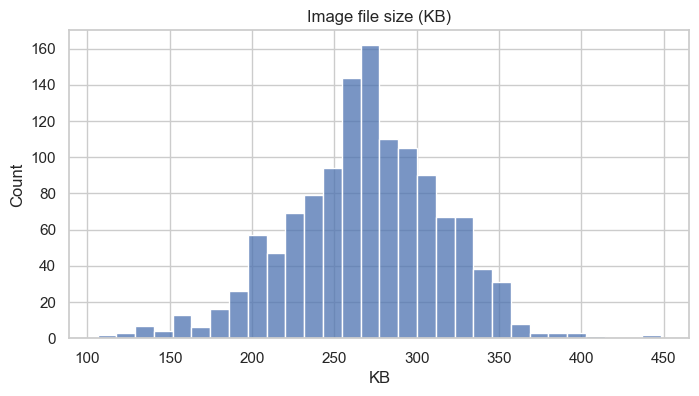

In [9]:
print("=== resolution (width, height) ===")
print(stats_df[["width", "height"]].value_counts().head())

sizes_kb = np.array([(IMAGE_DIR / f"{i}.jpg").stat().st_size for i in sample_df["image_id"]]) / 1024
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(sizes_kb, bins=30, ax=ax)
ax.set_title("Image file size (KB)")
ax.set_xlabel("KB")
plt.show()


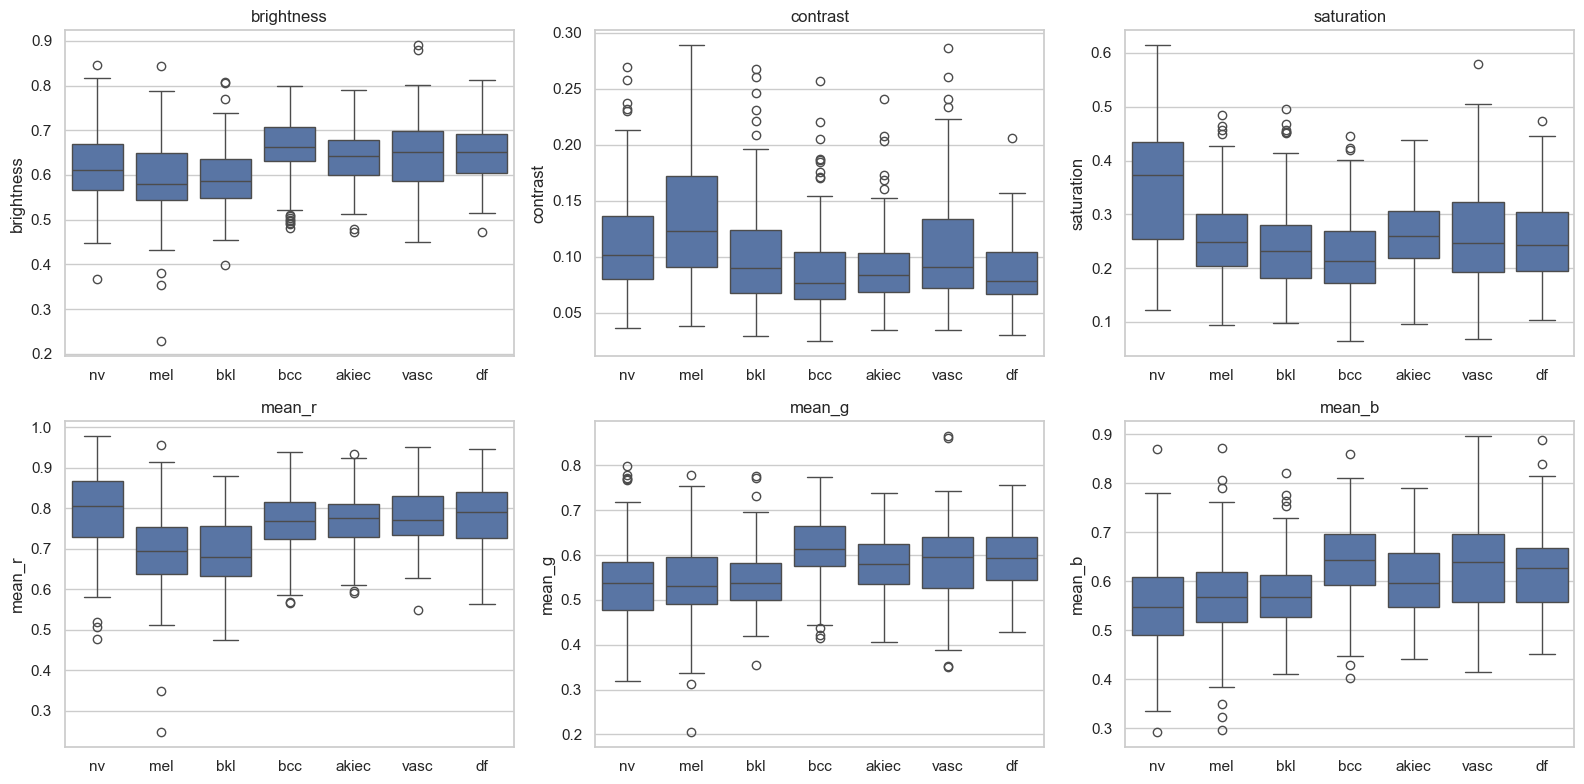

In [10]:
metrics = ["brightness", "contrast", "saturation", "mean_r", "mean_g", "mean_b"]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, m in zip(axes.ravel(), metrics):
    sns.boxplot(data=stats_df, x="dx", y=m, order=DX_ORDER, ax=ax)
    ax.set_title(m)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()


## 4. Sample Visualization

Representative images per class (each row is one lesion type).


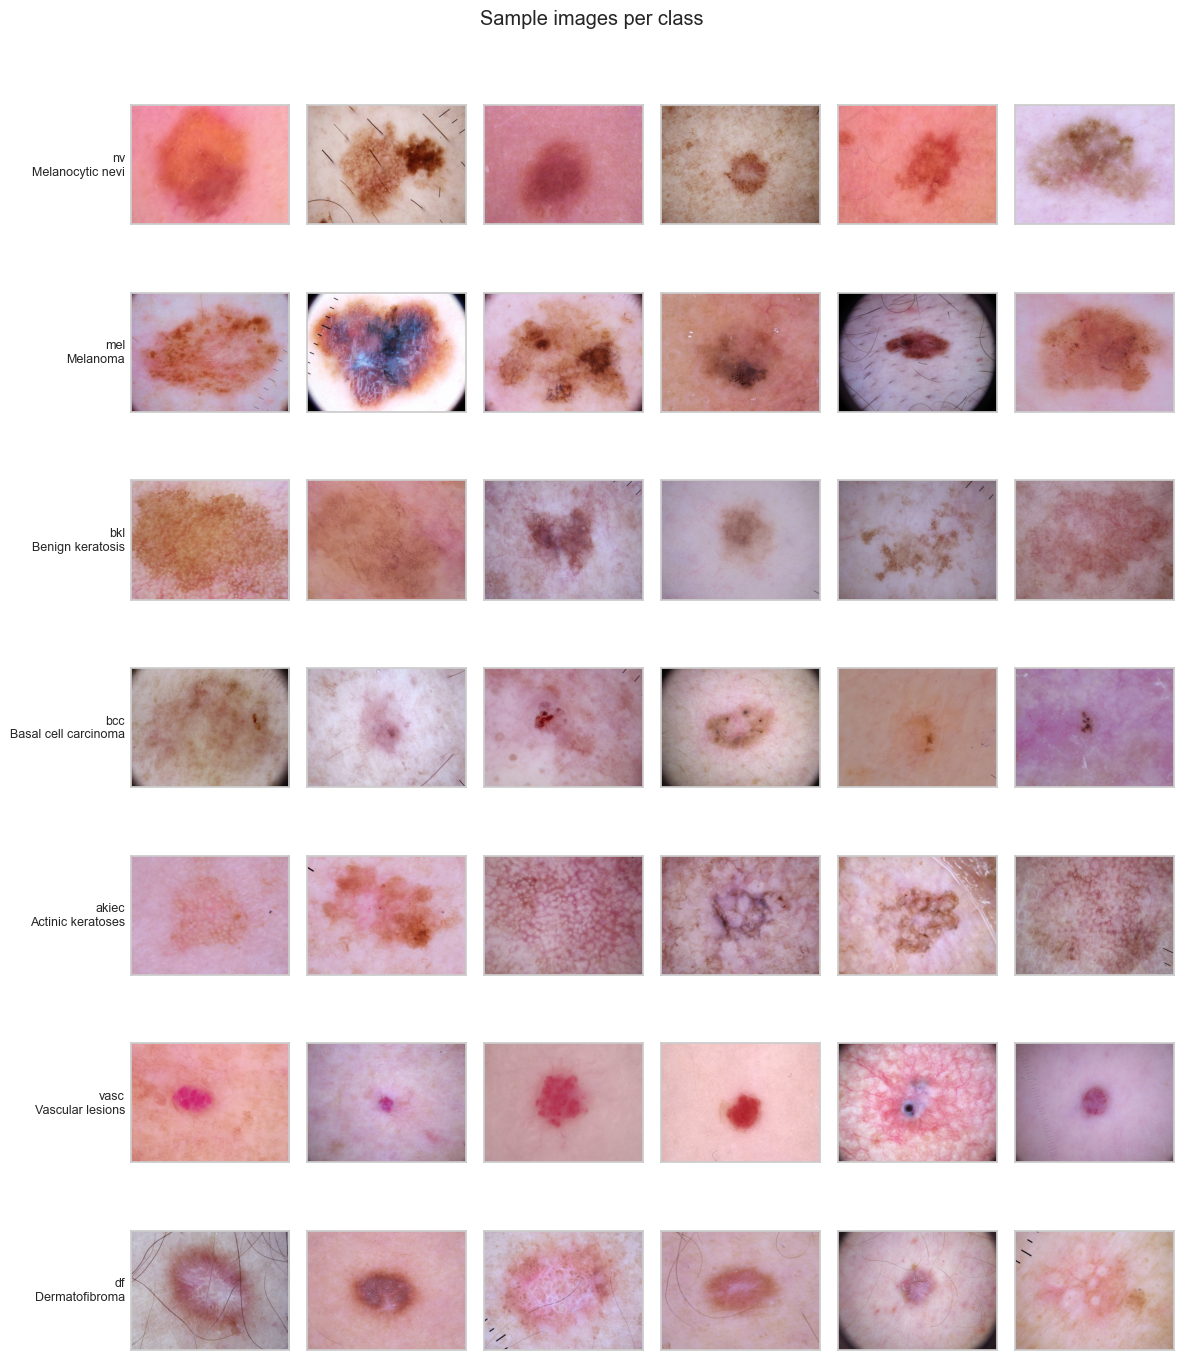

In [11]:
N_SHOW = 6
fig, axes = plt.subplots(len(DX_ORDER), N_SHOW, figsize=(N_SHOW * 2, len(DX_ORDER) * 2))
for row, dx in enumerate(DX_ORDER):
    ids = df[df["dx"] == dx]["image_id"].sample(N_SHOW, random_state=SEED).tolist()
    for col, image_id in enumerate(ids):
        ax = axes[row, col]
        ax.imshow(Image.open(IMAGE_DIR / f"{image_id}.jpg"))
        ax.set_xticks([])
        ax.set_yticks([])
    axes[row, 0].set_ylabel(f"{dx}\n{DX_FULL[dx]}", rotation=0, ha="right", va="center", fontsize=9)
fig.suptitle("Sample images per class", y=1.0)
plt.tight_layout()
plt.show()


## 5. Statistical Tests

Use a two-sample **Kolmogorov–Smirnov** test on per-image `brightness` to
quantify how separable each pair of classes is on this single axis. A larger KS
statistic means the two brightness distributions are more distinguishable. This
is a univariate proxy — real separability is multi-dimensional — but it flags
visually similar vs. distinct lesion pairs.


Most SIMILAR pair on brightness:  mel-bkl  KS=0.090
Most DIFFERENT pair on brightness: bkl-bcc  KS=0.490


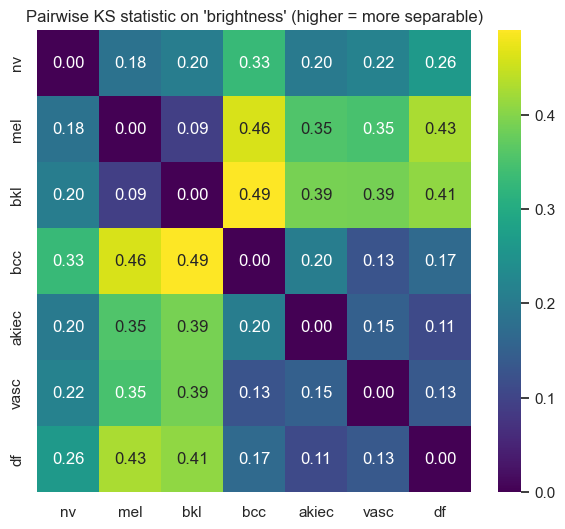

,class_a,class_b,ks_stat,p_value
0,mel,bkl,0.090000,3.935274e-01
1,akiec,df,0.110435,3.072379e-01
2,bcc,vasc,0.127606,1.200305e-01
3,vasc,df,0.134660,1.778193e-01
4,akiec,vasc,0.148239,4.566560e-02
5,bcc,df,0.166957,2.956964e-02
6,nv,mel,0.185000,2.082763e-03
7,nv,akiec,0.200000,6.486080e-04
8,bcc,akiec,0.205000,4.306111e-04
9,nv,bkl,0.205000,4.306111e-04


In [12]:
feature = "brightness"
ks_mat = pd.DataFrame(np.zeros((len(DX_ORDER), len(DX_ORDER))), index=DX_ORDER, columns=DX_ORDER)
results = []
for a, b in combinations(DX_ORDER, 2):
    xa = stats_df.loc[stats_df["dx"] == a, feature]
    xb = stats_df.loc[stats_df["dx"] == b, feature]
    ks = stats.ks_2samp(xa, xb)
    ks_mat.loc[a, b] = ks_mat.loc[b, a] = ks.statistic
    results.append((a, b, ks.statistic, ks.pvalue))

res = pd.DataFrame(results, columns=["class_a", "class_b", "ks_stat", "p_value"]).sort_values("ks_stat")
most_similar = res.iloc[0]
most_diff = res.iloc[-1]
print(f"Most SIMILAR pair on {feature}:  {most_similar.class_a}-{most_similar.class_b}  KS={most_similar.ks_stat:.3f}")
print(f"Most DIFFERENT pair on {feature}: {most_diff.class_a}-{most_diff.class_b}  KS={most_diff.ks_stat:.3f}")

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(ks_mat, annot=True, fmt=".2f", cmap="viridis", ax=ax)
ax.set_title(f"Pairwise KS statistic on '{feature}' (higher = more separable)")
plt.show()
res.reset_index(drop=True)


## 6. Insights & Modeling Implications

**Imbalance (~58x).** Accuracy is dominated by `nv` and misleading. Report
**per-class sensitivity**, **macro-F1**, and **macro-AUC**; train with
**class-weighted CE** and **Focal Loss** (the weights computed in §2 feed the
weighted-CE run directly).

**Leakage risk.** Multiple images share a `lesion_id`, so use a
**lesion-aware (grouped) train/val/test split** — never a plain random split —
to avoid the same lesion appearing in both train and test.

**Uniform geometry.** Images are a single resolution (600×450), so
`RandomResizedCrop(224)` and ImageNet normalization are safe, and ImageNet-
pretrained backbones transfer well — motivating **ResNet18** as the baseline,
with EfficientNet-B0 and ViT-Tiny as comparisons.

**Augmentation, medically aware.** Color statistics differ only modestly across
classes and some pairs are hard to separate on low-level features, so rely on
**transfer learning** and keep augmentation conservative: mild color jitter,
flips, and rotation **≤30°** to avoid destroying lesion morphology.

**Minority classes.** `df`, `vasc`, and `akiec` are scarce and will likely show
low recall; track them explicitly and consider a weighted sampler or light
oversampling in addition to the loss reweighting.
